# 02 · Predicting surface nutrients from MODIS

This notebook tests whether seven Aqua-MODIS surface variables can predict surface nitrate, phosphate, and silicate on a 1° grid, with particular attention to spatially realistic evaluation.


In [1]:
import os
os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "3")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap
import sklearn, gstools, tensorflow as tf

from modis_nutrients.config import REPO_ROOT, load_config
from modis_nutrients.dataset import load_table, spec_from_config
from modis_nutrients.spatial import RandomSplit, SpatialBlockSplit, variogram, nearest_distance_km
from modis_nutrients.models import make_model
from modis_nutrients.evaluate import run_grid, headline_table, split_table, feature_ablation, DEFAULT_ABLATION
from modis_nutrients.explain import shap_all_targets, mean_abs_shap_table
from modis_nutrients.plotting import plot_variogram, plot_split_map, plot_prediction_maps

FIG = REPO_ROOT / "docs" / "figures"
FIG.mkdir(parents=True, exist_ok=True)
print(f"scikit-learn {sklearn.__version__}, tensorflow {tf.__version__}, "
      f"shap {shap.__version__}, gstools {gstools.__version__}")

cfg = load_config()
spec = spec_from_config(cfg)
df = load_table(cfg["data"]["path"], spec)
lat, lon = df["lat"].to_numpy(), df["lon"].to_numpy()
Y = df[spec.targets].to_numpy(float)
X = df[["lat", "lon", *spec.features]]


scikit-learn 1.9.0, tensorflow 2.21.0, shap 0.51.0, gstools 1.7.0


## 1. Data

The predictors are seven Aqua-MODIS Level-3 surface variables, and the targets are WOA13 surface nitrate, phosphate, and silicate. MODIS is aggregated from about 9 km to the 1° WOA grid, so each valid ocean cell becomes one tabular sample.


In [2]:
print(f"{len(df)} usable cells, months {df.attrs['months']}")
df[[*spec.features, *spec.targets]].agg(["count", "min", "median", "max"]).T.round(3)

33412 usable cells, months [1]


,count,min,median,max
CHL,33412.0,0.008,0.159,14.963
APH,33412.0,0.002,0.013,0.641
FLU,33412.0,0.014,0.081,1.384
PIC,33412.0,0.000,0.000,0.097
POC,33412.0,17.281,55.187,1947.039
PAR,33412.0,3.887,42.243,64.393
SST,33412.0,-1.027,20.838,31.332
nitrate,33412.0,0.000,1.020,33.715
phosphate,33412.0,0.000,0.306,2.606
silicate,33412.0,0.000,2.552,97.694


## 2. Spatial evaluation

Because both the predictors and nutrient fields are spatially smooth, a random pixel split can overestimate generalization. I use a semivariogram to estimate the spatial correlation scale, then compare random splitting with spatial blocks and a geographic buffer.


fitted spatial scale: ~2224 km


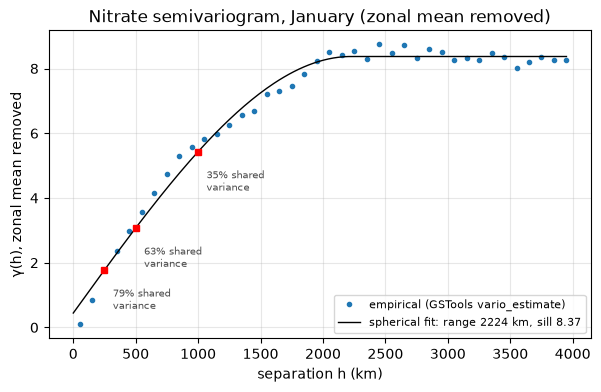

In [3]:
centers, gamma, model = variogram(lat, lon, df["nitrate"], **cfg["variogram"])
print(f"fitted spatial scale: ~{model.len_scale:.0f} km")
_ = plot_variogram(centers, gamma, model,
                   title="Nitrate semivariogram, January (zonal mean removed)",
                   path=FIG / "variogram_nitrate.png")
plt.show()


I divide the global grid into 20° spatial blocks and keep each block in a single partition. Because adjacent blocks can still touch, I remove training cells within 500 km of validation or test regions. The test set itself remains fixed.


{'train': 13562, 'buffer': 8572, 'test': 6305, 'val': 4973}
closest training cell to any test cell: 502 km


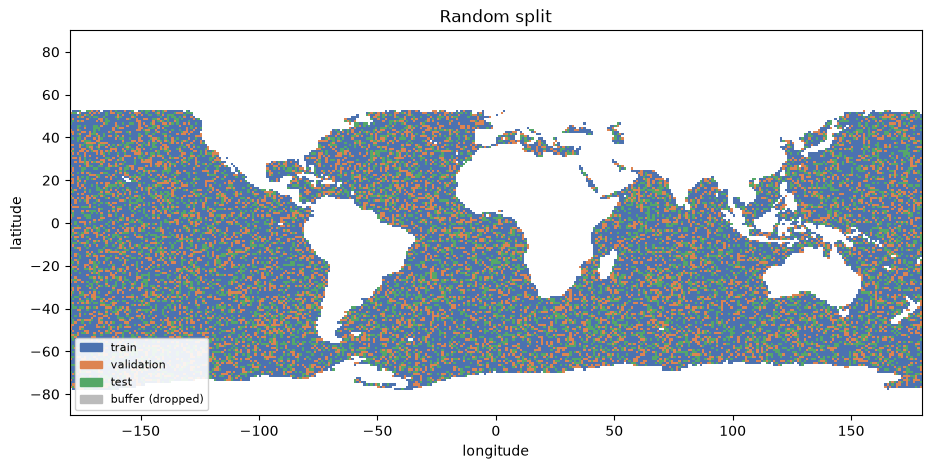

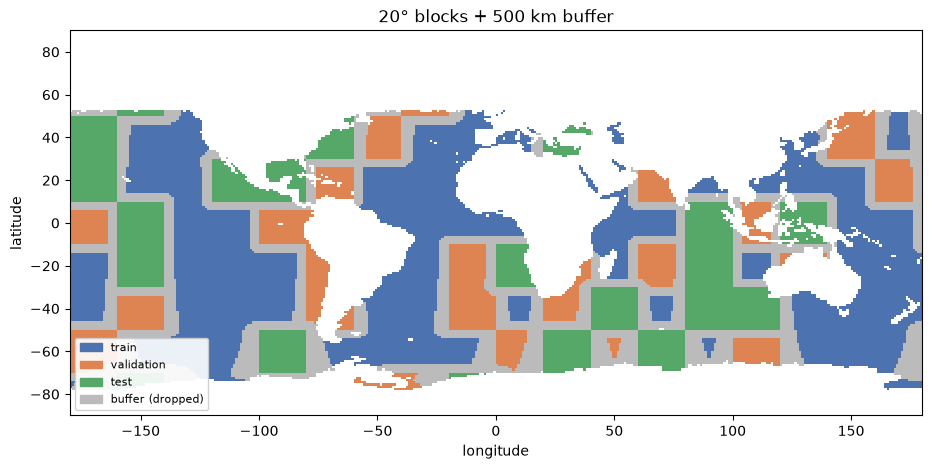

In [4]:
random_split = split_table(RandomSplit(seed=cfg["split"]["seed"]), df)
block_split = split_table(SpatialBlockSplit(cfg["split"]["block_deg"], cfg["split"]["buffer_km"],
                                            seed=cfg["split"]["seed"]), df)
print(pd.Series(block_split.labels()).value_counts().to_dict())
print(f"closest training cell to any test cell: {nearest_distance_km(lat[block_split.train], lon[block_split.train], lat[block_split.test], lon[block_split.test]).min():.0f} km")
_ = plot_split_map(random_split, lat, lon, title="Random split", path=FIG / "split_map_random.png")
_ = plot_split_map(block_split, lat, lon, title="20° blocks + 500 km buffer", path=FIG / "split_map_block_buffer.png")
plt.show()

## 3. Model comparison

I compare two location-only baselines with two models that use the seven MODIS predictors.

| Model | Inputs | Purpose |
|:--|:--|:--|
| Zonal mean | latitude | broad geographic baseline |
| Lat/lon KNN | latitude, longitude | local spatial-interpolation baseline |
| GBM | 7 MODIS variables | tree-based feature model |
| MLP | 7 MODIS variables | neural-network feature model |

The feature models use the same training-only preprocessing pipeline.


,gbm,latlon_knn,mlp,zonal_mean,n_train,n_val,n_test,n_dropped
split,,,,,,,,
block,0.930,0.877,0.929,0.818,20318,6789,6305,0
block_buffer,0.907,0.727,0.922,0.797,13562,4973,6305,8572
random,0.966,0.998,0.952,0.838,20046,6683,6683,0


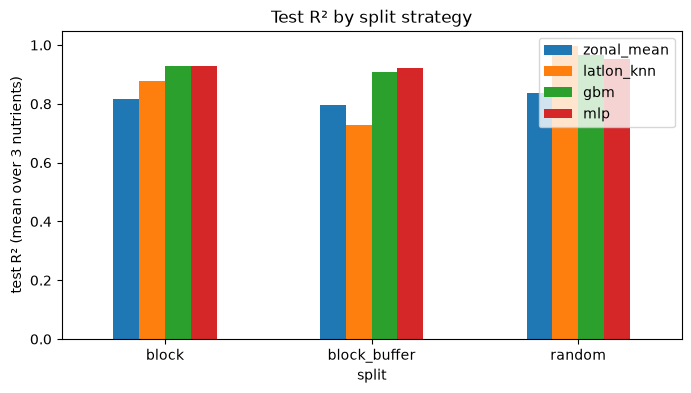

In [6]:
SPLITS = ["random", "block", "block_buffer"]
MODELS = ["zonal_mean", "latlon_knn", "gbm", "mlp"]
long, results = run_grid(cfg, SPLITS, MODELS, df=df, verbose=False)
head = headline_table(long)
display(head.round(3))
ax = head[MODELS].plot.bar(figsize=(8, 4), rot=0, ylabel="test R² (mean over 3 nutrients)",
                           title="Test R² by split strategy")
ax.figure.savefig(FIG / "headline_test_r2.png", dpi=150, bbox_inches="tight")
plt.show()

Under the random split, the location-only KNN reaches nearly perfect R², showing that geographic proximity alone can reproduce much of the nutrient map. With spatial blocks and a 500 km buffer, KNN performance drops substantially, while GBM and MLP retain much more of their skill. I therefore use the block-plus-buffer split as the main evaluation.


## 4. Feature ablation

I retrain the feature models using SST only, SST + PAR, ocean-colour variables only, and all seven inputs to see which predictors carry the spatially generalizable signal.


In [8]:
ablation_table = pd.concat(
    {model_name: feature_ablation(cfg, ["random", "block_buffer"], DEFAULT_ABLATION, model_name=model_name,
                                  df=df, verbose=False)
     for model_name in ["gbm", "mlp"]},
    axis=1)
ablation_table.round(3)

gbm                 mlp             
             random block_buffer random block_buffer
sst_only      0.896        0.874  0.896        0.878
sst_par       0.929        0.890  0.924        0.905
ocean_colour  0.832        0.679  0.850        0.733
all           0.966        0.907  0.952        0.922

For this January climatological experiment, SST alone retains most of the blocked-test skill, while adding the other MODIS variables gives a smaller improvement.


## 5. Spatial errors

I map the held-out WOA targets, GBM predictions, and residuals to check whether the errors have coherent geographic structure.


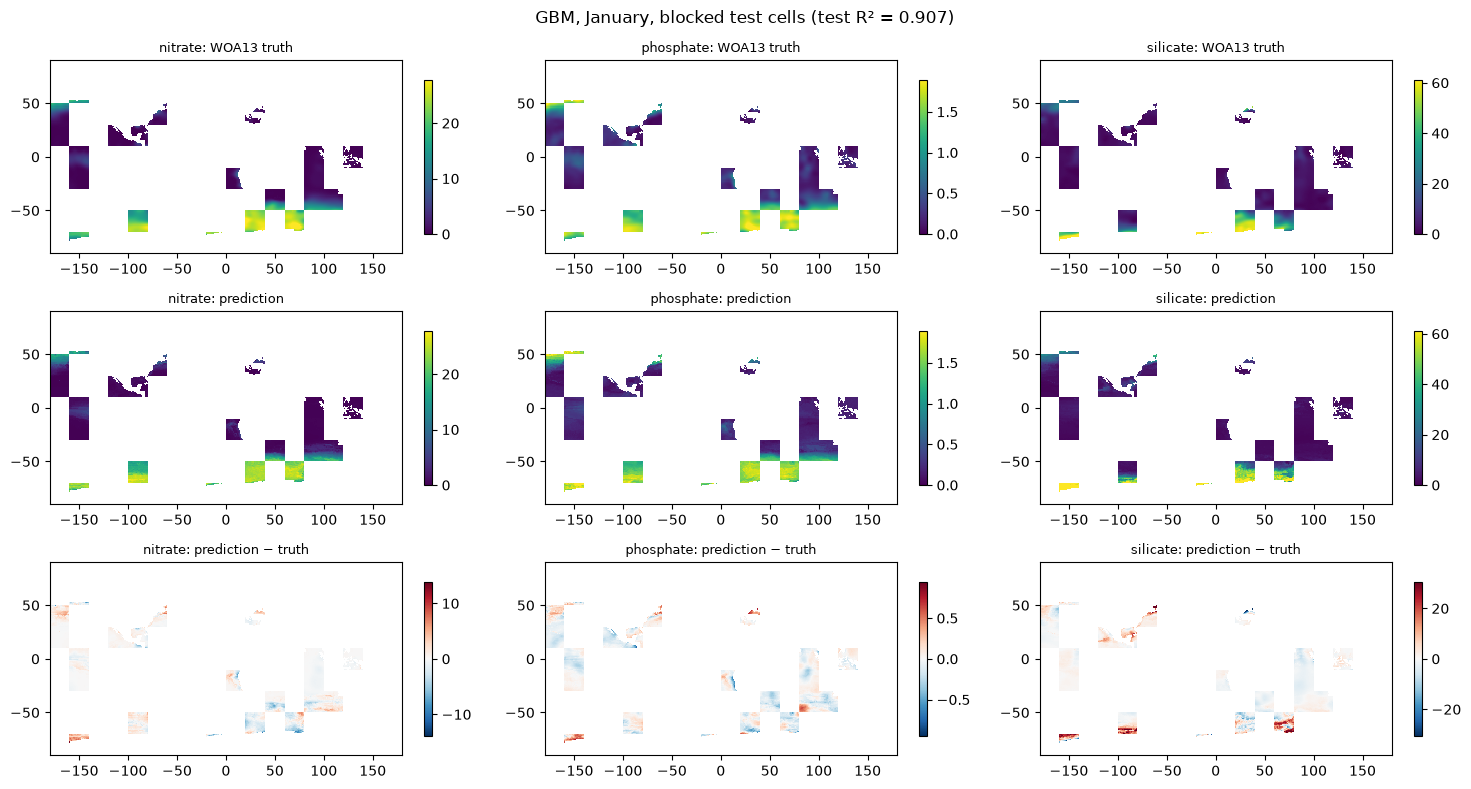

In [9]:
res_gbm = next(r for r in results if r.split_name == "block_buffer" and r.model_name == "gbm")
_ = plot_prediction_maps(lat[block_split.test], lon[block_split.test], Y[block_split.test],
                         res_gbm.predictions["test"], spec.targets,
                         title=f"GBM, January, blocked test cells (test R² = {res_gbm.metrics['test'].loc['mean', 'r2']:.3f})",
                         path=FIG / "test_maps_gbm_january.png")
plt.show()

## 6. SHAP

I use SHAP on the spatially held-out test cells to compare what the GBM and MLP rely on. GBM uses TreeExplainer; the MLP uses a model-agnostic permutation explainer. The table reports mean absolute SHAP values for each feature and nutrient.


In [10]:
tr, va, te = block_split.train, block_split.val, block_split.test
shap_ex = {}
for model_name in ["gbm", "mlp"]:
    m = make_model(model_name, cfg).fit(X.iloc[tr], Y[tr], X.iloc[va], Y[va])
    shap_ex[model_name] = shap_all_targets(
        m, X.iloc[tr], X.iloc[te], max_explain=500
    )

shap_table = pd.concat(
    {name: mean_abs_shap_table(ex, spec.targets) for name, ex in shap_ex.items()},
    axis=1,
)
display(shap_table.sort_values(("gbm", "nitrate"), ascending=False).round(3))


gbm                        mlp                   
    nitrate phosphate silicate nitrate phosphate silicate
SST   7.377     0.477    9.851   6.966     0.456    8.108
FLU   0.451     0.030    0.504   0.835     0.039    1.884
PAR   0.365     0.022    1.371   0.503     0.032    2.732
CHL   0.313     0.025    0.445   1.348     0.107    4.053
PIC   0.240     0.023    0.873   0.437     0.033    2.214
APH   0.215     0.020    0.544   0.391     0.074    0.618
POC   0.107     0.009    0.336   0.479     0.026    2.663

SST has the largest mean absolute SHAP value for all three nutrients in both models, consistent with the feature-ablation result.


## Takeaways

- A random pixel split strongly rewards geographic interpolation, so spatially structured evaluation is important for this smooth global dataset.
- Under the 20° block + 500 km buffer split, GBM and MLP retain substantially more skill than the location-only KNN baseline.
- In the January 1° climatological experiment, SST carries most of the predictive signal, consistent with both feature ablation and SHAP.
